In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from deep_translator import GoogleTranslator
import openpyxl

translator = GoogleTranslator(source="auto", target="en")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


# Loading the dataset

Combining the datasets

In [2]:
reddit_df = pd.read_csv("reddit_data.csv")
local_df = pd.read_excel("Phase2_Local.xlsx")
global_df = pd.read_excel("Phase2_Global.xlsx")
jf_reddit_df = pd.read_csv("reddit_data_jf.csv")
migs_reddit_df = pd.read_excel("reddit_freelance_ofw_clean.xlsx")

In [3]:
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

reddit_df = clean_cols(reddit_df)
local_df = clean_cols(local_df)
global_df = clean_cols(global_df)
jf_reddit_df = clean_cols(jf_reddit_df)
migs_reddit_df = clean_cols(migs_reddit_df)

In [4]:
jf_df = jf_reddit_df[
    jf_reddit_df["intern_notes"] != "not relevant"
].drop(columns=["unnamed:_12"], errors="ignore").copy()

In [5]:
all_dfs = [local_df, global_df, reddit_df, jf_df, migs_reddit_df]
combined_df = pd.concat(all_dfs, ignore_index=True)

Checking all unique subreddits

In [6]:
combined_df["source_subreddit"].dropna().unique()

array(['r/phcareers', 'r/Philippines', 'r/jobs', 'r/recruitinghell',
       'r/jobsearchhacks', 'r/careerguidance', 'phcareers', 'r/freelance',
       'r/OFWs'], dtype=object)

In [7]:
combined_df

,source_subreddit,post_url,post_title,post_or_comment,content_(full_text),date_posted,upvotes_/_score,theme_tag,platform_mentioned,philippine_context?,notable_quote,intern_notes
0,r/phcareers,https://www.reddit.com/r/phcareers/comments/1n...,Use of LinkedIN Connections to Secure Unposted...,post,Madami akong nababasa dito about difficulty of...,2025-09,1263,UX,LinkedIn,Yes,"Yes, totoo, ako nga na merong 19-years of expe...",NaN
1,r/phcareers,https://www.reddit.com/r/phcareers/comments/1l...,"Nasabihan ako ng ""Lipat ka kasi ng lipat ng ku...",post,"M \[28\] and an engineer, this July I will be ...",2025-06,401,PROCESS,NaN,Yes,"Nagparegular lang ako, then I am now rendering...",NaN
2,r/phcareers,https://www.reddit.com/r/phcareers/comments/1l...,Job hunting is draining and demoralizing,post,I am a first-time job seeker and my experience...,2025-07,284,UX,NaN,Yes,I have long known that graduating from a prest...,NaN
3,r/phcareers,https://www.reddit.com/r/phcareers/comments/1p...,Hired before I ended the year!,post,"Hi, guys! 👋🏼 December is almost ending and I j...",2025-12,272,GHOSTING,NaN,Yes,"Napaisip pa ako, “Pag ito hindi ako tinanggap,...",NaN
4,r/phcareers,https://www.reddit.com/r/phcareers/comments/1m...,Regret as a fresh graduate kung kelan may degr...,post,I’m a recent graduate of Psychology and only r...,2025-08,262,GHOSTING,NaN,Yes,I don’t have much luck landing in a VA role an...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
558,r/OFWs,https://www.reddit.com/r/OFWs/comments/1sdr1g8...,(Need insights) Nail Technician in Saudi Arabia,post,Hi I am F26 and have applied to various jobs o...,04/2026,2,RELEVANCE,NaN,Yes,is it worth the risk or should I just find a ...,NaN
559,r/OFWs,https://www.reddit.com/r/OFWs/comments/1s9dni1...,Cannot generate Balik manggagawa OEC online,post,Hello po. So umuwi po ako last week from AU ka...,04/2026,2,PROCESS,NaN,Yes,"Ang kaso, ngayon, ayaw naman mag proceed nung ...",NaN
560,r/OFWs,https://www.reddit.com/r/OFWs/comments/1r0u624...,Workabroad-legit agencies,post,"Hi all, sino po dito nkapag apply na thru work...",02/2026,2,PROCESS,NaN,Yes,"Hi all, sino po dito nkapag apply na thru work...",NaN
561,r/OFWs,https://www.reddit.com/r/OFWs/comments/1r0u624...,Workabroad-legit agencies,comment,Legit lahat ng agencies sa workabroad.ph kasi ...,02/2026,2,OVERSEAS,WorkAbroad.ph,Yes,Legit lahat ng agencies sa workabroad.ph kasi ...,NaN


Renaming `phcareers` to `r/phcareers` since they are the same thing

In [46]:
combined_df["source_subreddit"] = combined_df["source_subreddit"].replace(
    "phcareers", "r/phcareers"
)

# Ensuring Quality Standards

In [47]:
yes_count = (combined_df["philippine_context?"] == "Yes").sum()
total = len(combined_df)

percentage = (yes_count / total) * 100
print(f"{percentage:.2f}%")

66.96%


At least 30% of entries should are from Philippine-focused subreddits (r/Philippines, r/phcareers, r/OFW). 

In [48]:
combined_df["theme_tag"].value_counts()

theme_tag
GHOSTING      114
PROCESS       100
EMOTIONAL      97
UX             77
RELEVANCE      53
SCAM           43
VISIBILITY     30
OTHER          22
OVERSEAS       18
VISIBLITY       8
OFW             1
Name: count, dtype: int64

At least 5 different Theme Tags are represented

In [49]:
combined_df["source_subreddit"].dropna().unique()

array(['r/phcareers', 'r/Philippines', 'r/jobs', 'r/recruitinghell',
       'r/jobsearchhacks', 'r/careerguidance', 'r/freelance', 'r/OFWs'],
      dtype=object)

Entries span at least 3 different subbreddits (7 in this case)

Total number of entries

In [50]:
len(combined_df)

563

In [51]:
combined_df["source_subreddit"].value_counts()

source_subreddit
r/phcareers         310
r/freelance          66
r/OFWs               38
r/jobs               35
r/jobsearchhacks     35
r/recruitinghell     35
r/Philippines        29
r/careerguidance     15
Name: count, dtype: int64

In [52]:
combined_df.loc[
    combined_df["source_subreddit"] == "r/jobsearchhacks",
    "post_url"
].dropna().unique()

array(['https://www.reddit.com/r/jobsearchhacks/comments/1qxizav/i_stopped_getting_ghosted_by_recruiters_after_i/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1rnu44b/quit_my_job_with_no_offer_lined_up_because_of_my/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1m3mz41/finally_happened/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1kxlzc1/this_is_the_biggest_job_search_hack_ive_ever/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1ogfrhm/works_like_a_charm/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1me3u0m/it_seems_like_job_market_is_opening_up_a_bit/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1ktexgd/cold_messaging_on_linkedin_is_humbling_af/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1lyxtf7/my_partner_and_her_family_severely_underestimate/',
       'https://www.reddit.com/r/jobsearchhacks/comments/1rkr4e3/45_months_250_applications_and_180_ghosts_later_i/',
       'https://www.redd

# Converting the Content to English

In [53]:
def translate_to_english(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return text
        return translator.translate(str(text))
    except Exception:
        return text

In [54]:
combined_df["content_en"] = combined_df["content_(full_text)"].apply(translate_to_english)

# EDA

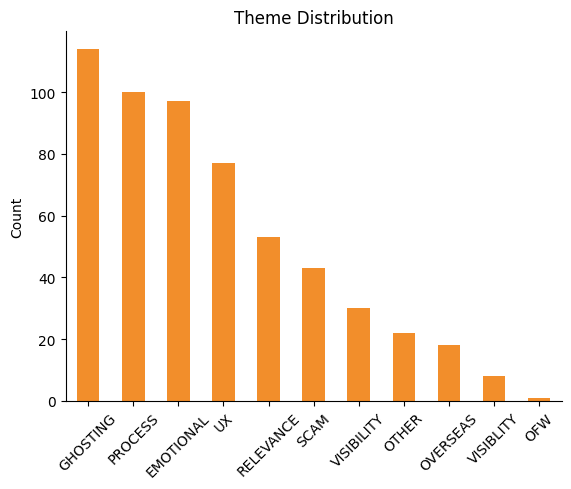

In [55]:
import matplotlib.pyplot as plt

theme_counts = combined_df["theme_tag"].value_counts()

plt.figure()
ax = theme_counts.plot(kind="bar", color="#F28E2B")

plt.title("Theme Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

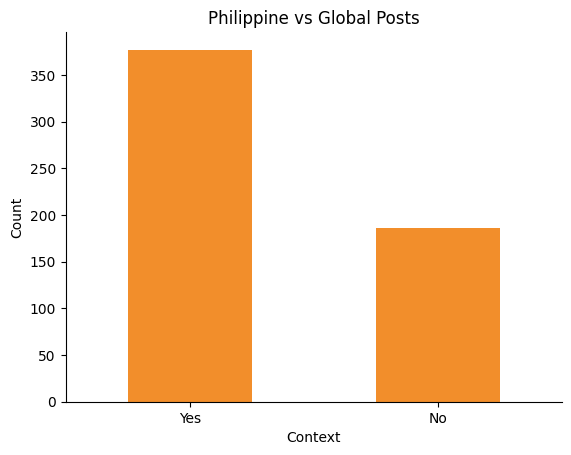

In [56]:
ph_counts = combined_df["philippine_context?"].value_counts()

plt.figure()
ax = ph_counts.plot(kind="bar", color="#F28E2B")

plt.title("Philippine vs Global Posts")
plt.xlabel("Context")
plt.ylabel("Count")
plt.xticks(rotation=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# # of K

In [ ]:
def evaluate_k(df, theme, k_range=range(2, 8)):
    subset = df[df["theme_tag"] == theme].copy()
    
    texts = subset["content_en"].fillna("").tolist()
    
    if len(texts) < 10:
        print(f"Not enough data for {theme}")
        return
    
    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(embeddings)

        if len(set(labels)) < 2:
            continue

        sil = silhouette_score(embeddings, labels)
        db = davies_bouldin_score(embeddings, labels)
        ch = calinski_harabasz_score(embeddings, labels)
        inertia = kmeans.inertia_

        results.append({
            "k": k,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "inertia": inertia
        })

    results_df = pd.DataFrame(results)
    print(f"\n===== {theme} =====")
    print(results_df)

    plt.figure()
    plt.plot(results_df["k"], results_df["inertia"], marker="o")
    plt.title(f"{theme} - Elbow Method (Inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.show()

    return results_df


===== PROCESS =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.047760        4.013863           6.039592  73.669518
1  3    0.038015        3.688647           4.939482  70.980637
2  4    0.049988        3.315544           5.061153  67.529175
3  5    0.043126        3.399889           4.215828  66.419601
4  6    0.035494        3.306779           3.537837  65.822914
5  7    0.037008        2.971374           3.471523  63.898380


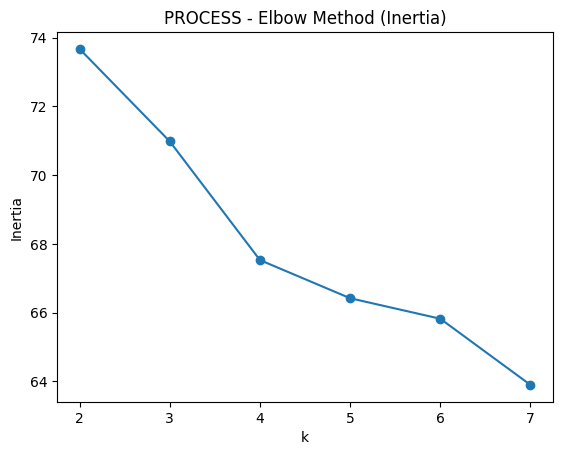

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.047760,4.013863,6.039592,73.669518
1,3,0.038015,3.688647,4.939482,70.980637
2,4,0.049988,3.315544,5.061153,67.529175
3,5,0.043126,3.399889,4.215828,66.419601
4,6,0.035494,3.306779,3.537837,65.822914
5,7,0.037008,2.971374,3.471523,63.898380


In [91]:
evaluate_k(combined_df, "PROCESS")


===== UX =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.064973        3.409310           6.341198  52.183937
1  3    0.051107        3.380546           5.025200  49.828533
2  4    0.049780        3.337740           4.125406  48.391827
3  5    0.037966        3.101334           3.690460  46.966682
4  6    0.030020        2.981433           3.271552  45.998432
5  7    0.028711        2.951786           3.067096  44.814568


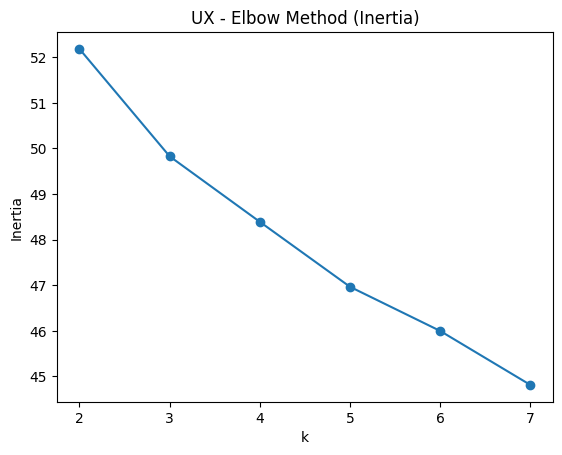

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.064973,3.409310,6.341198,52.183937
1,3,0.051107,3.380546,5.025200,49.828533
2,4,0.049780,3.337740,4.125406,48.391827
3,5,0.037966,3.101334,3.690460,46.966682
4,6,0.030020,2.981433,3.271552,45.998432
5,7,0.028711,2.951786,3.067096,44.814568


In [92]:
evaluate_k(combined_df, "UX")


===== GHOSTING =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.052445        3.911747           7.233490  74.008018
1  3    0.041890        3.686534           5.111699  72.143211
2  4    0.041449        3.538977           4.706990  69.824287
3  5    0.039433        3.417860           4.440947  67.747025
4  6    0.039357        3.190066           4.086349  66.253731
5  7    0.038435        2.910033           3.928577  64.564613


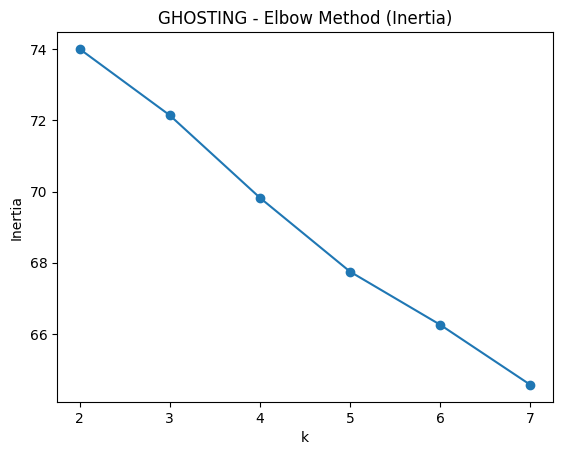

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.052445,3.911747,7.233490,74.008018
1,3,0.041890,3.686534,5.111699,72.143211
2,4,0.041449,3.538977,4.706990,69.824287
3,5,0.039433,3.417860,4.440947,67.747025
4,6,0.039357,3.190066,4.086349,66.253731
5,7,0.038435,2.910033,3.928577,64.564613


In [93]:
evaluate_k(combined_df, "GHOSTING")


===== EMOTIONAL =====
   k  silhouette  davies_bouldin  calinski_harabasz    inertia
0  2    0.041973        4.390484           4.746330  62.479126
1  3    0.011071        3.960400           3.950964  60.513706
2  4    0.013360        4.064124           3.342050  59.216640
3  5    0.016068        3.582704           3.344287  57.272968
4  6    0.013710        3.552340           2.862455  56.685329
5  7    0.004354        3.376211           2.679986  55.656727


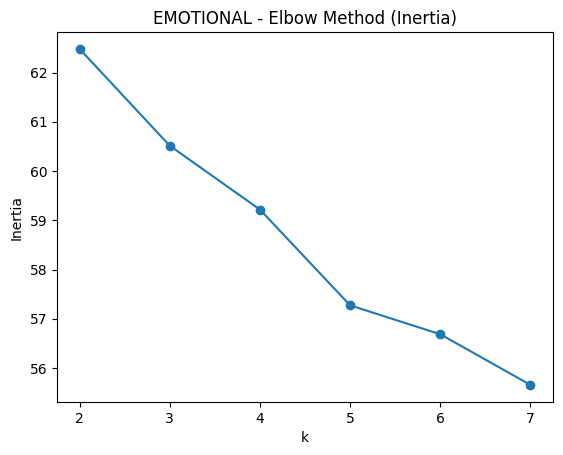

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.041973,4.390484,4.746330,62.479126
1,3,0.011071,3.960400,3.950964,60.513706
2,4,0.013360,4.064124,3.342050,59.216640
3,5,0.016068,3.582704,3.344287,57.272968
4,6,0.013710,3.552340,2.862455,56.685329
5,7,0.004354,3.376211,2.679986,55.656727


In [94]:
evaluate_k(combined_df, "EMOTIONAL")

# Advanced Methods

My plan here was to run K-means clusters on each theme tag and uncover what specific events were occurring. 

In [95]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1028.10it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [96]:
def cluster_theme(df, theme, k=2):
    subset = df[df["theme_tag"] == theme].copy()

    texts = subset["content_en"].fillna("").tolist()

    # embeddings
    embeddings = model.encode(texts, show_progress_bar=False)
    embeddings = normalize(embeddings)

    # clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    subset["sub_cluster"] = labels

    print(f"\n===== {theme} =====")

    # print ALL content per cluster
    for i in range(k):
        print(f"\n===== Sub-cluster {i} =====\n")

        cluster_texts = subset[subset["sub_cluster"] == i]["content_en"]

        for idx, text in enumerate(cluster_texts):
            print(f"{idx+1}. {text}\n")

## PROCESS

In [97]:
cluster_theme(combined_df, "PROCESS")


===== PROCESS =====

===== Sub-cluster 0 =====

1. Just wanna share my story after being laid off, hoping that applying will help those who are still ongoing. I have more than 5 YOE as a developer, I consider myself around senior level and I still felt the difficulty of applying now compared to a few years ago.

Here's my record so far:

* 31 applications sent
* 13 initial interviews
* 4 rejections received
* 4 technical interviews
* 2 final interviews
* 1 job offer

I was laid off last January, then decided to chill first since there was severance pay. Around Feb-March, I only passed 5 applications. At that time I could still choose the one I applied for, I still wanted the type of perfect company that was just right for my current tech skills. I revised my resume for each application, researched a bunch of stuff until I could come up with a "perfect" resume.

Around the last week of March, I'm a bit pressured since I'm the sole breadwinner of the family and my budget is slowly runni

## UX

In [98]:
cluster_theme(combined_df, "UX")


===== UX =====

===== Sub-cluster 0 =====

1. Been applying for jobs ever since I (F, 24) was still doing my OJT last April since I know from experience that job hunting is hard (was in culinary field before I got an injury and enrolled in an Associates Degree so at least I have a degree of some kind). So far, out of the 100+ jobs I applied to on Indeed I'm not getting a single interview. I graduated multimedia and even have a portfolio prepared. I worked so hard to graduate as Second Honors so I could at least have an advantage of some kind.

The more I spend time on Indeed, Kalibrr, and Jobstreet and apply to jobs the more I want to crash out, I even went to 2 job fairs lately and still no final interviews. I'm even starting to wonder if I'm the problem, like not having a 4 year degree (Planning to get a Degree once I have the money). Would even accept a low ball job offer at this point so I could at least get peace of mind from being unemployed.

I'm planning to get Code Camp certs

## GHOSTING

In [99]:
cluster_theme(combined_df, "GHOSTING")


===== GHOSTING =====

===== Sub-cluster 0 =====

1. Hi guys! 👋🏼 December is almost ending and I just want to share my gratitude for this year, if you don't mind.

I graduated in 2024 and took a break for almost a year. Just racket first while resting. And when the time came for me to start job hunting, we had a family emergency. So, I had to pause for a while. 

When I returned to job hunting, it was hard!!! In just one job site, I have already sent 100+ applications, but they were either ghosted, rejected, or replied too late. I don't know how many emails I sent, and how many interviews I attended. Jusko, I've even paid lower than minimum wage (pls don't copy it 😭😭😭) because I'm so desperate to get a job. It's also rare that they accept fresh grads or those who don't have much experience. 

I also joined Facebook groups... and finally!!! Also received a response that was not a rejection (😆). That seems to be my last straw. I even thought, "If this doesn't accept me, I really don't wa

## EMOTIONAL

In [100]:
cluster_theme(combined_df, "EMOTIONAL")


===== EMOTIONAL =====

===== Sub-cluster 0 =====

1. Just wanted to say the job market is horrendous and soul crushing. In the past 6 months I've had:
- 1000+ applications
- 4 jobs interview me
- 0 offers
- Insurmountable ghosting

Four years of experience in finance. Several more in supply chain. Three in the service industry. I want to give up, this feels pointless. What can I even do, if anything, other than hurry up and wait? 😔

2. I don't know what to do with this offer. I know I must sound ungrateful especially when its so hard to get a job right now.

For background, Ive been out of work for a year. My old company was toxic and I hated it. The job itself was unfufilling and opportunities for growth were none. 

Fast forward, i am approached by a recruiter on LinkedIn. Id never heard of the company, the job was a bit out of my scope but they were happy to interview me. The interview went great and I was invited for the second interview. Again, this went great! Researching this c